In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import hashlib

```shell
uv run batch_train.py configs/dnerf_ablation/trex.yaml \
--laptop-8gb \
--matrix-preset cartesian \
--axes isotropy,appearance,sorting,pruning,ess \
--sorting-options sort,sort_free \
--output-root output/ablations_no_usplat_dropout_off \
--set 'save_iterations=[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]' \
--set use_usplat=False \
--set random_dropout_prob=0.0 \
--set lambda_rdr=0.0 \
--no-quota-reservation && uv run batch_train.py configs/dnerf_ablation/trex.yaml \
--laptop-8gb \
--matrix-preset cartesian \
--axes isotropy,appearance,sorting,pruning,ess \
--sorting-options sort \
--output-root output/ablations_usplat_sort_dropout_off \
--set 'save_iterations=[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]' \
--set use_usplat=True \
--set usplat_motion_window=3 \
--set random_dropout_prob=0.0 \
--set lambda_rdr=0.0 \
--no-quota-reservation
```

In [42]:
BASE_DIR = Path("output/ablations_no_usplat_dropout_off/trex/")
OUTPUT_CSV = BASE_DIR.parent / "trex_checkpoint_eval_metrics_all.csv"

SCENE_NAME = "trex"
CONFIG_PATH = "configs/dnerf_ablation/trex.yaml"
MATRIX_PRESET = "cartesian"
USE_USPLAT = False
DROPOUT_DEFAULT = "no_dropout"


FINAL_COLUMNS = [
    "status",
    "run_hash",
    "scene_name",
    "variant_name",
    "variant_index",
    "matrix_preset",
    "isotropy",
    "appearance",
    "sorting",
    "pruning",
    "dropout",
    "ess",
    "use_usplat",
    "config_path",
    "generated_config_path",
    "model_path",
    "checkpoint_index",
    "checkpoint_filename",
    "checkpoint_path",
    "checkpoint_name_iteration",
    "eval_requested_split",
    "eval_split_used",
    "eval_checkpoint_iteration",
    "psnr",
    "ssim",
    "lpips",
    "render_fps",
    "peak_eval_vram_mb",
    "final_gaussian_count",
    "checkpoint_size_bytes",
    "checkpoint_size_mb",
    "training_wall_clock_sec_at_checkpoint",
    "metrics_jsonl_path",
    "metrics_csv_path",
    "created_at",
]


def stable_hash(text: str, length: int = 16) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:length]


def parse_variant_dirname(dirname: str) -> dict:
    """
    Supports both:

    5-part folders:
        isotropic--rgb--sort--no_pruning--no_ess

    6-part folders:
        isotropic--rgb--sort--no_pruning--no_dropout--no_ess
    """
    parts = dirname.split("--")

    if len(parts) == 5:
        isotropy, appearance, sorting, pruning, ess = parts
        dropout = DROPOUT_DEFAULT

    elif len(parts) == 6:
        isotropy, appearance, sorting, pruning, dropout, ess = parts

    else:
        raise ValueError(f"Unexpected variant folder name: {dirname}")

    variant_parts = [
        isotropy,
        appearance,
        sorting,
        pruning,
        dropout,
        ess,
    ]

    return {
        "isotropy": isotropy,
        "appearance": appearance,
        "sorting": sorting,
        "pruning": pruning,
        "dropout": dropout,
        "ess": ess,
        "variant_name": "__".join(variant_parts),
    }


def value_or(record: dict, key: str, fallback):
    value = record.get(key, pd.NA)
    return fallback if pd.isna(value) or value == "" else value


rows = []
created_at = datetime.now().replace(microsecond=0).isoformat()

variant_dirs = sorted(
    p for p in BASE_DIR.iterdir()
    if p.is_dir()
)

for variant_index, variant_dir in enumerate(variant_dirs):
    metrics_csv = variant_dir / "checkpoint_eval_metrics.csv"

    if not metrics_csv.exists():
        print(f"Skipping, no metrics file: {metrics_csv}")
        continue

    parsed = parse_variant_dirname(variant_dir.name)

    df = pd.read_csv(metrics_csv, skipinitialspace=True)
    df.columns = df.columns.str.strip()

    for col in df.columns:
        if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].astype("string").str.strip()

    for _, row in df.iterrows():
        record = row.to_dict()

        record["run_hash"] = value_or(
            record,
            "run_hash",
            stable_hash(str(variant_dir.resolve())),
        )

        record["scene_name"] = value_or(
            record,
            "scene_name",
            SCENE_NAME,
        )

        record["variant_name"] = value_or(
            record,
            "variant_name",
            parsed["variant_name"],
        )

        record["variant_index"] = variant_index
        record["matrix_preset"] = MATRIX_PRESET

        record["isotropy"] = value_or(
            record,
            "isotropy",
            parsed["isotropy"],
        )

        record["appearance"] = value_or(
            record,
            "appearance",
            parsed["appearance"],
        )

        record["sorting"] = value_or(
            record,
            "sorting",
            parsed["sorting"],
        )

        record["pruning"] = value_or(
            record,
            "pruning",
            parsed["pruning"],
        )

        record["dropout"] = value_or(
            record,
            "dropout",
            parsed["dropout"],
        )

        record["ess"] = value_or(
            record,
            "ess",
            parsed["ess"],
        )

        record["use_usplat"] = USE_USPLAT
        record["config_path"] = CONFIG_PATH

        record["model_path"] = value_or(
            record,
            "model_path",
            str(variant_dir.resolve()),
        )

        record["metrics_csv_path"] = str(metrics_csv.resolve())
        record["metrics_jsonl_path"] = str(
            (variant_dir / "checkpoint_eval_metrics.jsonl").resolve()
        )

        record["training_wall_clock_sec_at_checkpoint"] = value_or(
            record,
            "training_wall_clock_sec_at_checkpoint",
            pd.NA,
        )

        # chkpnt_best.pth may have no number in filename, so use loaded eval iteration.
        record["checkpoint_name_iteration"] = value_or(
            record,
            "checkpoint_name_iteration",
            record.get("eval_checkpoint_iteration", pd.NA),
        )

        record["created_at"] = created_at

        rows.append(record)


combined = pd.DataFrame(rows)

# Ensure all final columns exist before selecting.
for col in FINAL_COLUMNS:
    if col not in combined.columns:
        combined[col] = pd.NA

# Add MB versions for byte columns before final column ordering.
byte_cols = [
    c for c in combined.columns
    if c.endswith("_bytes") or "bytes" in c.lower()
]

for col in byte_cols:
    mb_col = col.replace("_bytes", "_mb")
    combined[mb_col] = pd.to_numeric(combined[col], errors="coerce") / (1024 ** 2)
    print("Normalized column:", mb_col)

# Ensure newly derived columns exist too.
for col in FINAL_COLUMNS:
    if col not in combined.columns:
        combined[col] = pd.NA

final_df = combined[FINAL_COLUMNS].copy()

final_df.to_csv(OUTPUT_CSV, index=False)

print(f"Wrote {len(final_df)} rows to {OUTPUT_CSV}")

Normalized column: checkpoint_size_mb
Wrote 352 rows to output/ablations_no_usplat_dropout_off/trex_checkpoint_eval_metrics_all.csv


In [ ]:
model_spec_cols = [
    "run_hash",
    "scene_name",
    "variant_name",
    "variant_index",
    "matrix_preset",
    "isotropy",
    "appearance",
    "sorting",
    "pruning",
    "dropout",
    "ess",
    "checkpoint_index",
    "checkpoint_name_iteration",
    "eval_checkpoint_iteration",
]

metric_cols = [
    "psnr",
    "ssim",
    "lpips",
    "render_fps",
    "peak_eval_vram_mb",
    "final_gaussian_count",
    "checkpoint_size_mb",
    "training_wall_clock_sec_at_checkpoint",
]

In [31]:
keep_cols = [c for c in model_spec_cols + metric_cols if c in df.columns]
print("Keep:", keep_cols)

df_clean = final_df[keep_cols].copy()
df_clean.head()

Keep: ['run_hash', 'scene_name', 'variant_name', 'isotropy', 'appearance', 'sorting', 'pruning', 'ess', 'checkpoint_index', 'checkpoint_name_iteration', 'eval_checkpoint_iteration', 'psnr', 'ssim', 'lpips', 'render_fps', 'peak_eval_vram_mb', 'final_gaussian_count', 'training_wall_clock_sec_at_checkpoint']


,run_hash,scene_name,variant_name,isotropy,appearance,sorting,pruning,ess,checkpoint_index,checkpoint_name_iteration,eval_checkpoint_iteration,psnr,ssim,lpips,render_fps,peak_eval_vram_mb,final_gaussian_count,training_wall_clock_sec_at_checkpoint
0,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,0,1000.0,1000,24.935668,0.943198,0.131948,2681.015460,52.025391,6098,12.051873
1,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,1,2000.0,2000,27.277221,0.963123,0.072265,1043.881000,59.732910,37045,16.360973
2,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,2,3000.0,3000,28.038140,0.969383,0.052161,723.241720,74.733398,93740,21.230597
3,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,3,4000.0,4000,28.684475,0.973552,0.043559,563.424895,86.816406,138160,27.026341
4,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,4,5000.0,5000,28.540549,0.973881,0.039664,564.573249,93.671387,161090,33.599653


In [ ]:
df_clean.head(n=3).to_string()

'  status          run_hash scene_name                                            variant_name  variant_index matrix_preset     isotropy appearance sorting                    pruning     dropout  ess  use_usplat                       config_path                                                                                                                                                                                                                                generated_config_path                                                                                                                                                                                                                    model_path  checkpoint_index checkpoint_filename                                                                                                                                                                                                                              checkpoint_path  checkpoint_

In [46]:
df_clean[df_clean.isna().any(axis=1)]

,run_hash,scene_name,variant_name,isotropy,appearance,sorting,pruning,ess,checkpoint_index,checkpoint_name_iteration,eval_checkpoint_iteration,psnr,ssim,lpips,render_fps,peak_eval_vram_mb,final_gaussian_count,training_wall_clock_sec_at_checkpoint


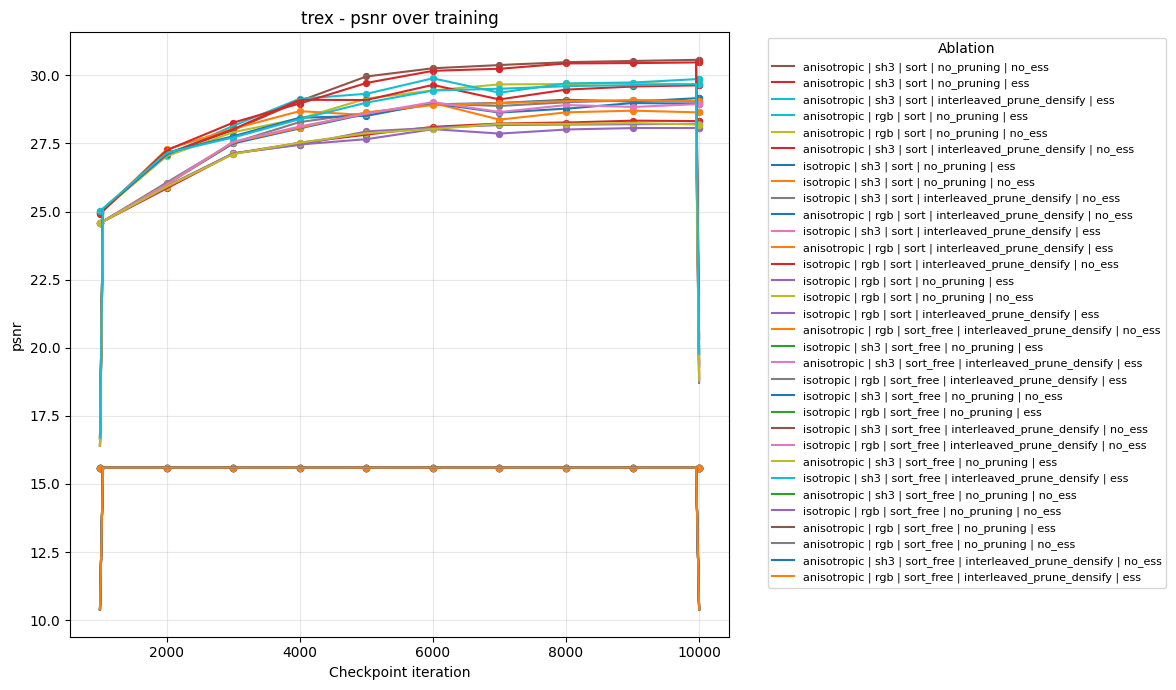

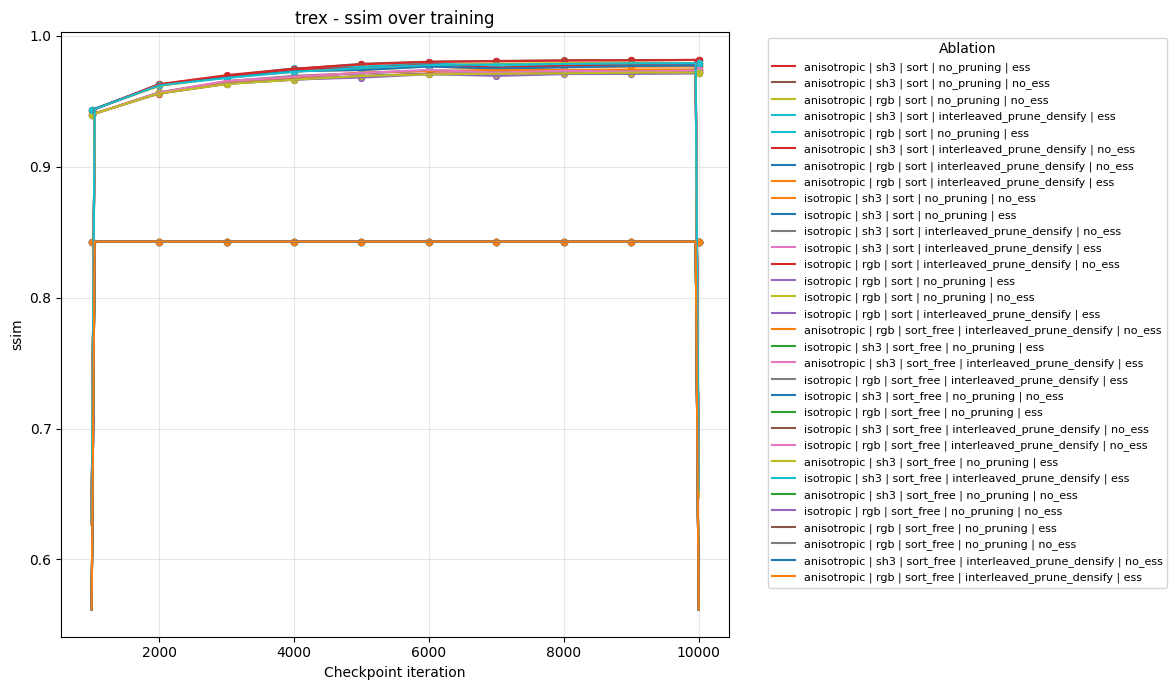

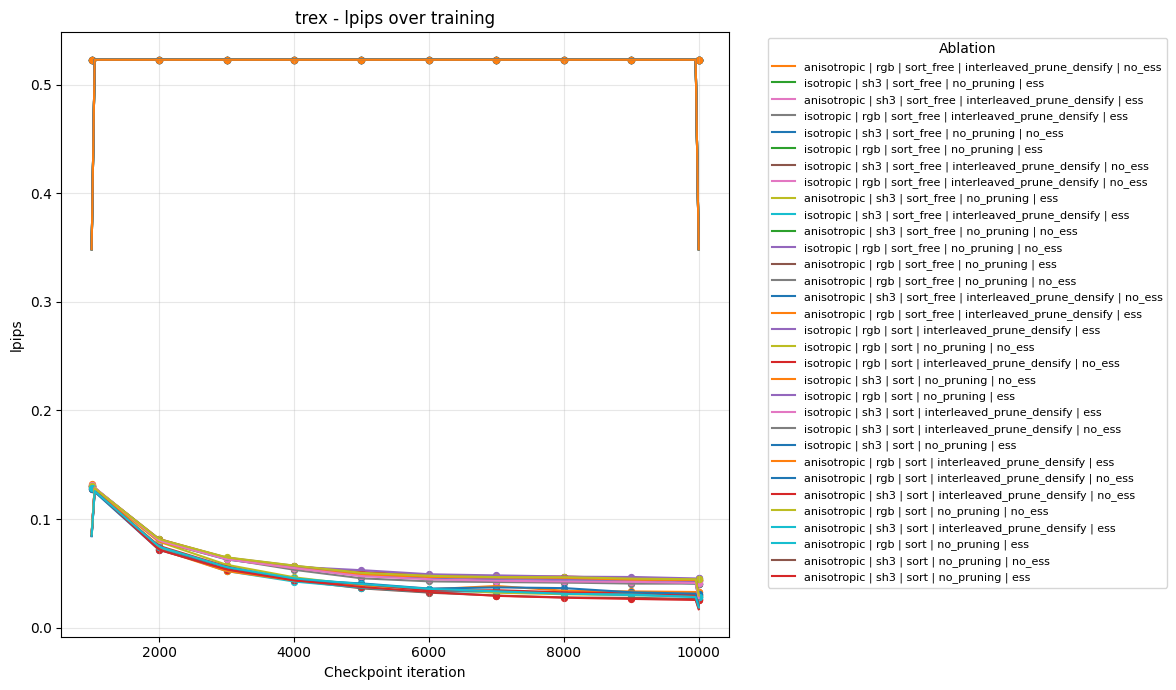

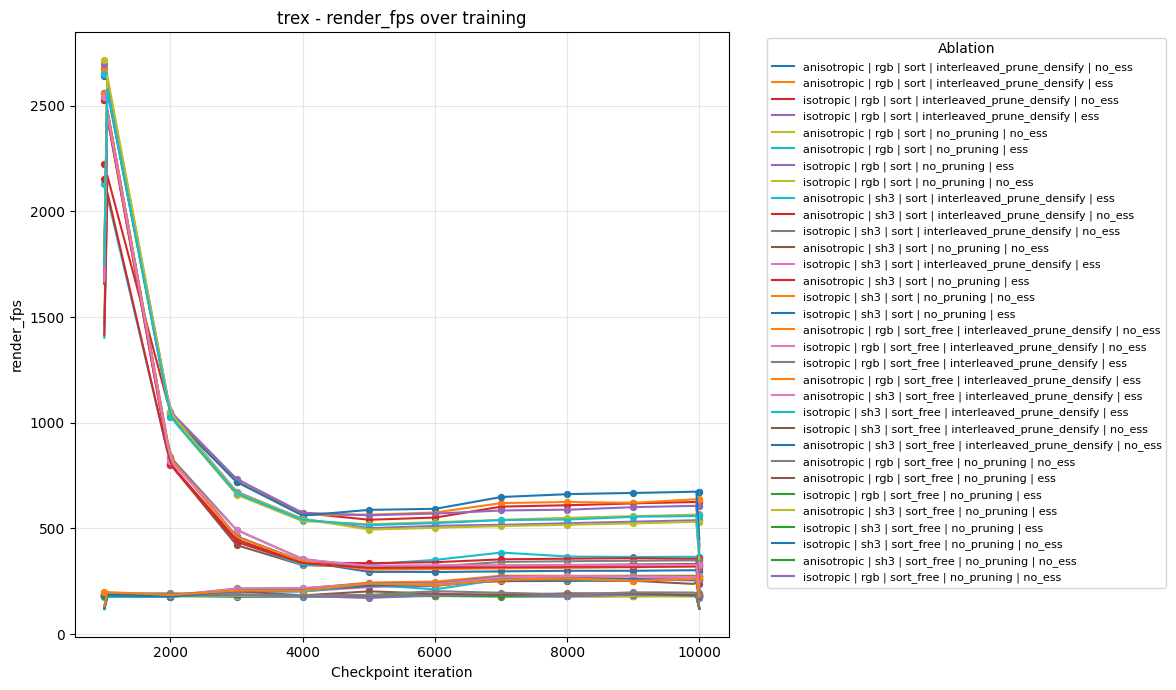

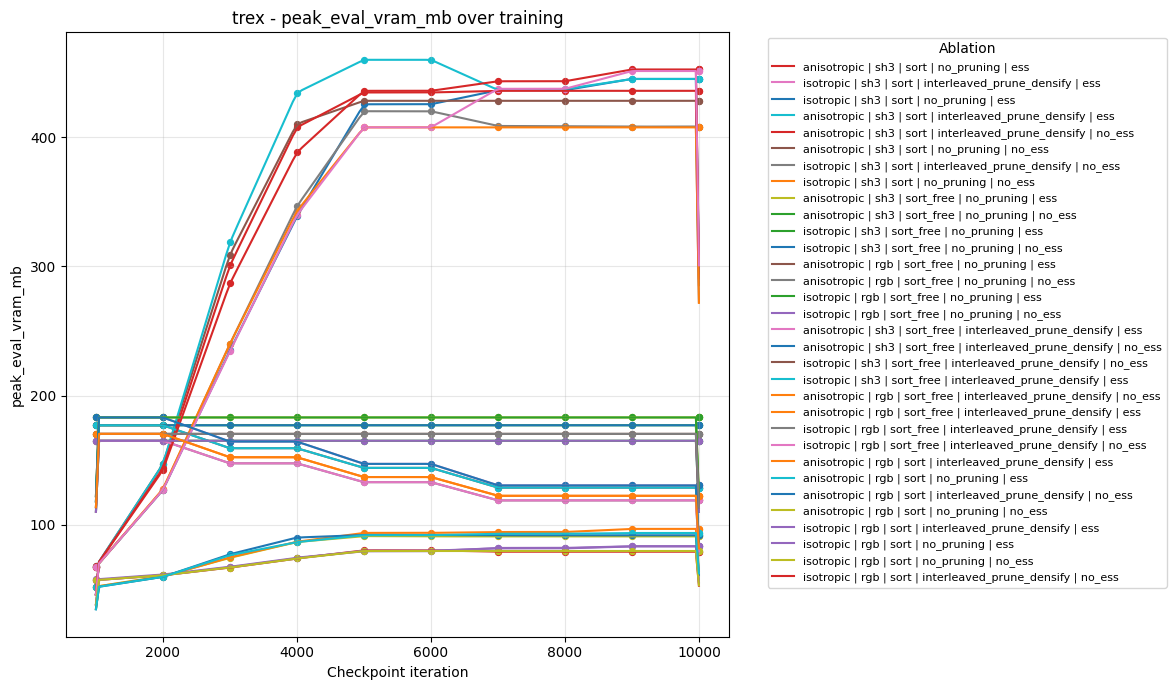

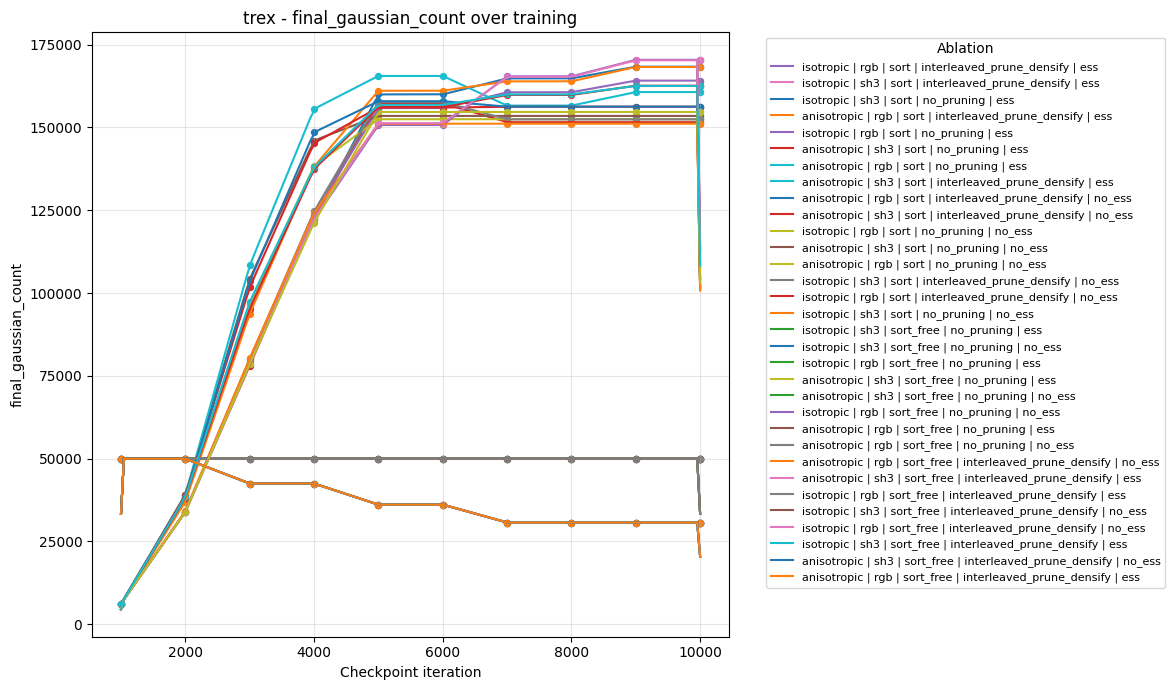

Skipping missing metric: checkpoint_size_mb


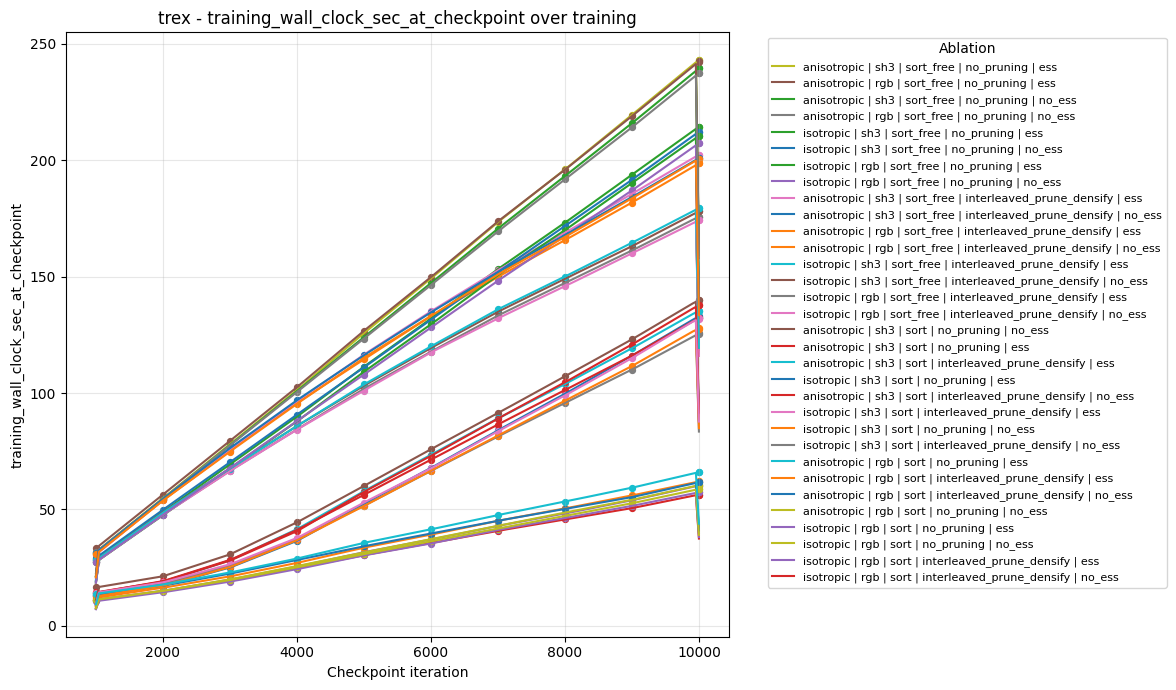

In [23]:
dataset_name = "trex"

plot_df = df_clean.copy()
plot_df = plot_df[plot_df["scene_name"] == dataset_name].copy()


boolean_label_map = {
    "isotropy": {
        True: "isotropy",
        False: "anisotropy",
    },
    "appearance": {
        True: "appearance",
        False: "no appearance",
    },
    "sorting": {
        True: "sorting",
        False: "no sorting",
    },
    "pruning": {
        True: "pruning",
        False: "no pruning",
    },
    "dropout": {
        True: "dropout",
        False: "no dropout",
    },
    "ess": {
        True: "ess",
        False: "no ess",
    },
}


def normalize_bool(value):
    if isinstance(value, bool):
        return value

    if isinstance(value, (np.bool_,)):
        return bool(value)

    if isinstance(value, str):
        value_lower = value.strip().lower()
        if value_lower in {"true", "1", "yes", "y"}:
            return True
        if value_lower in {"false", "0", "no", "n"}:
            return False

    return None


def make_ablation_label(row):
    cols = ["isotropy", "appearance", "sorting", "pruning", "dropout", "ess"]
    parts = []

    for col in cols:
        if col not in row or pd.isna(row[col]):
            continue

        value = row[col]
        bool_value = normalize_bool(value)

        if col in boolean_label_map and bool_value is not None:
            parts.append(boolean_label_map[col][bool_value])
        else:
            parts.append(str(value))

    return " | ".join(parts)


labels = (
    plot_df
    .sort_values(["eval_checkpoint_iteration"])
    .groupby("run_hash")
    .first()
    .apply(make_ablation_label, axis=1)
    .to_dict()
)

plot_df["ablation_label"] = plot_df["run_hash"].map(labels)


def smooth_line_numpy(xs, ys, points=200, window=3):
    """
    Lightweight smoothing without scipy.
    Uses linear interpolation + moving average.
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)

    if len(xs) < 3:
        return xs, ys

    x_smooth = np.linspace(xs.min(), xs.max(), points)
    y_interp = np.interp(x_smooth, xs, ys)

    window = max(1, int(window))
    if window <= 1:
        return x_smooth, y_interp

    kernel = np.ones(window) / window
    y_smooth = np.convolve(y_interp, kernel, mode="same")

    return x_smooth, y_smooth


def plot_metric_over_training(df, metric, x_col="eval_checkpoint_iteration"):
    plt.figure(figsize=(12, 7))

    legend_items = []

    for run_hash, run_df in df.groupby("run_hash"):
        run_df = run_df.sort_values(x_col)

        xs = run_df[x_col].to_numpy(dtype=float)
        ys = run_df[metric].to_numpy(dtype=float)

        valid = np.isfinite(xs) & np.isfinite(ys)
        xs = xs[valid]
        ys = ys[valid]

        if len(xs) == 0:
            continue

        label = run_df["ablation_label"].iloc[0]

        x_smooth, y_smooth = smooth_line_numpy(xs, ys)

        line, = plt.plot(x_smooth, y_smooth)
        plt.scatter(xs, ys, s=18, color=line.get_color())

        final_value = ys[-1]
        legend_items.append((final_value, line, label))

    plt.title(f"{dataset_name} - {metric} over training")
    plt.xlabel("Checkpoint iteration")
    plt.ylabel(metric)
    plt.grid(alpha=0.3)

    legend_items = sorted(
        legend_items,
        key=lambda item: item[0],
        reverse=True,
    )

    handles = [item[1] for item in legend_items]
    legend_labels = [item[2] for item in legend_items]

    plt.legend(
        handles,
        legend_labels,
        title="Ablation",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8,
    )

    plt.tight_layout()
    plt.show()


for metric in metric_cols:
    if metric not in plot_df.columns:
        print(f"Skipping missing metric: {metric}")
        continue

    plot_metric_over_training(plot_df, metric)

In [55]:
dataset = "trex"
iteration = 10_000

iter_col = "eval_checkpoint_iteration" if "eval_checkpoint_iteration" in df.columns else "checkpoint_name_iteration"

df_summary = df_clean[
    (df_clean["scene_name"] == dataset)
    & (df_clean[iter_col] == iteration)
].copy()

# One record per checkpoint/run hash
dedupe_cols = ["run_hash", iter_col]
if "created_at" in df_summary.columns:
    df_summary = df_summary.sort_values("created_at")

df_summary = (
    df_summary
    .drop_duplicates(subset=dedupe_cols, keep="last")
    .sort_values(["variant_name"])
    .reset_index(drop=True)
)

summary_cols = [c for c in model_spec_cols + metric_cols if c in df_summary.columns]
df_summary = df_summary[summary_cols]

print("records:", len(df_summary))
print("unique run_hash:", df_summary["run_hash"].nunique())
print("iteration:", iteration)

df_summary

records: 32
unique run_hash: 32
iteration: 10000


,run_hash,scene_name,variant_name,isotropy,appearance,sorting,pruning,ess,checkpoint_index,checkpoint_name_iteration,eval_checkpoint_iteration,psnr,ssim,lpips,render_fps,peak_eval_vram_mb,final_gaussian_count,training_wall_clock_sec_at_checkpoint
0,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,10,10000.0,10000,28.638542,0.976647,0.032892,636.097597,96.756836,168261,61.973689
1,87bb98fc13398bf1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,no_ess,10,10000.0,10000,28.957284,0.977425,0.031329,673.910304,91.804199,156287,61.643466
2,e427e2ad99873613,trex,anisotropic__rgb__sort__no_pruning__ess,anisotropic,rgb,sort,no_pruning,ess,10,10000.0,10000,29.680585,0.979148,0.028084,562.898805,93.581543,162548,65.988165
3,34ae7b9dfd73fa78,trex,anisotropic__rgb__sort__no_pruning__no_ess,anisotropic,rgb,sort,no_pruning,no_ess,10,10000.0,10000,29.645533,0.979331,0.029290,567.915656,90.950684,152496,60.389828
4,fb8b4446f8510597,trex,anisotropic__rgb__sort_free__interleaved_prune...,anisotropic,rgb,sort_free,interleaved_prune_densify,ess,10,10000.0,10000,15.600850,0.842924,0.522818,264.193642,122.385254,30707,200.572310
5,05417c6c50ff6206,trex,anisotropic__rgb__sort_free__interleaved_prune...,anisotropic,rgb,sort_free,interleaved_prune_densify,no_ess,10,10000.0,10000,15.600850,0.842924,0.522818,276.512159,122.385254,30707,198.581429
6,bdfefe006dd2d037,trex,anisotropic__rgb__sort_free__no_pruning__ess,anisotropic,rgb,sort_free,no_pruning,ess,10,10000.0,10000,15.600850,0.842924,0.522818,187.349576,170.357422,50000,242.347373
7,d59160b967a9c487,trex,anisotropic__rgb__sort_free__no_pruning__no_ess,anisotropic,rgb,sort_free,no_pruning,no_ess,10,10000.0,10000,15.600850,0.842924,0.522818,188.113052,170.357422,50000,237.365820
8,34ddbf3051e13c4c,trex,anisotropic__sh3__sort__interleaved_prune_dens...,anisotropic,sh3,sort,interleaved_prune_densify,ess,10,10000.0,10000,29.864486,0.979250,0.028591,364.242722,445.213867,160695,135.216789
9,4ced9752145fc511,trex,anisotropic__sh3__sort__interleaved_prune_dens...,anisotropic,sh3,sort,interleaved_prune_densify,no_ess,10,10000.0,10000,29.632133,0.978495,0.030259,360.280852,436.057617,156271,131.996465


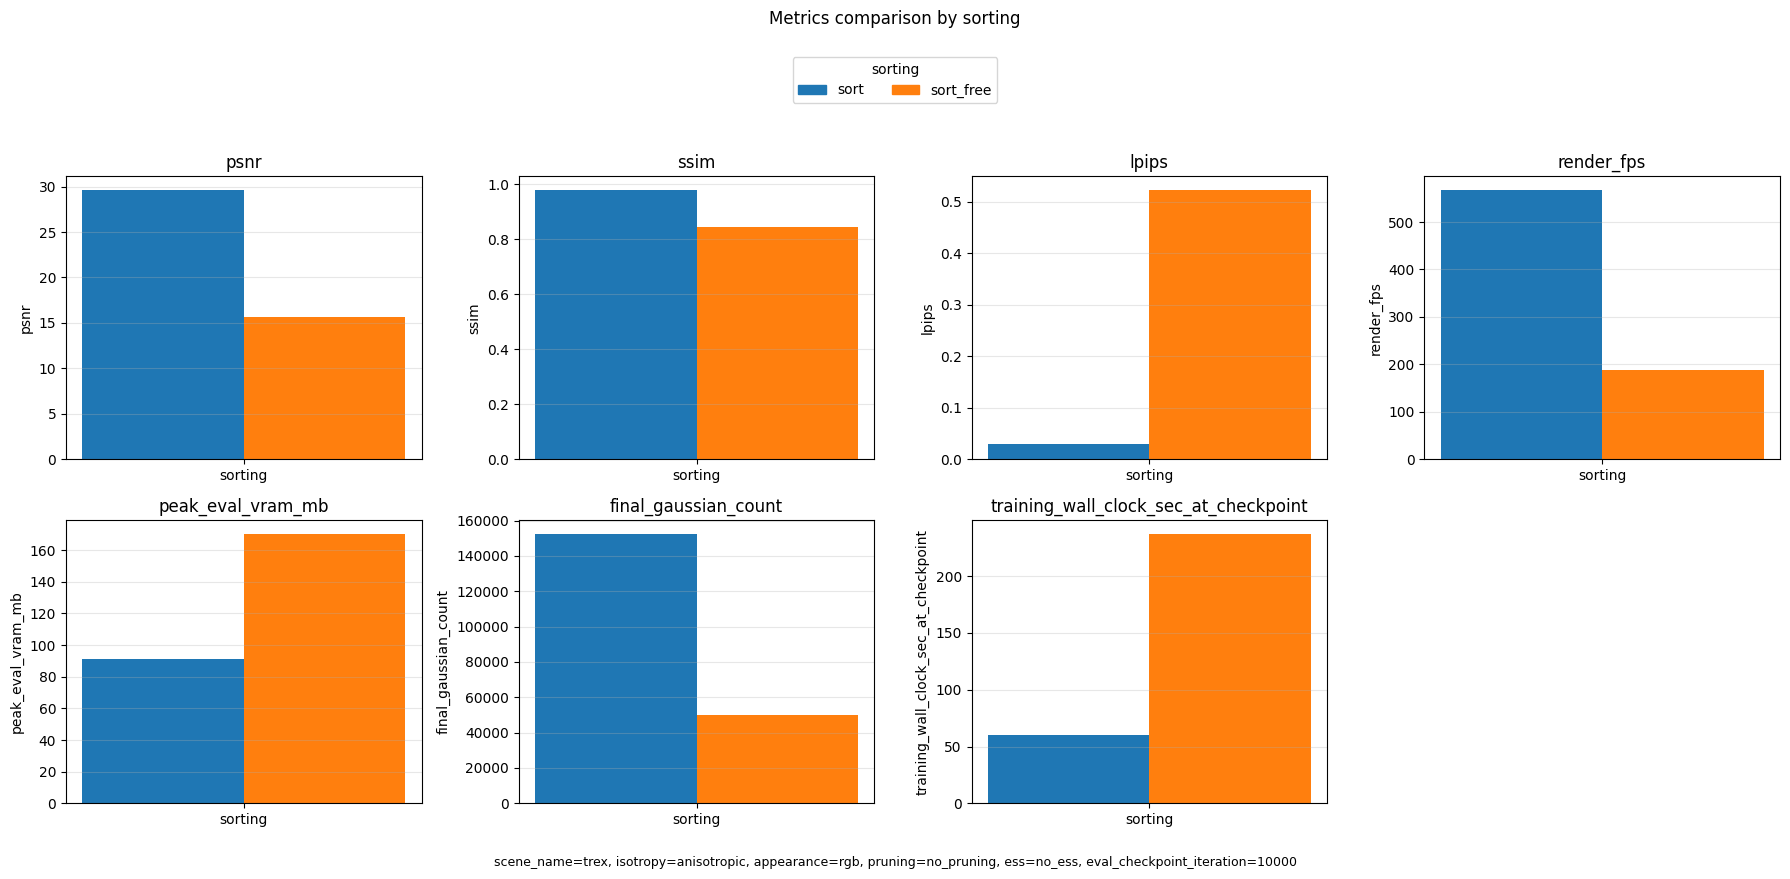

,sorting,psnr,ssim,lpips,render_fps,peak_eval_vram_mb,final_gaussian_count,training_wall_clock_sec_at_checkpoint
0,sort,29.645533,0.979331,0.029290,567.915656,90.950684,152496.0,60.389828
1,sort_free,15.600850,0.842924,0.522818,188.113052,170.357422,50000.0,237.365820


In [56]:
compare_col = "sorting"

fixed_values = {
    "scene_name": "trex",
    "matrix_preset": "cartesian",
    "isotropy": "anisotropic",
    "appearance": "rgb",
    "sorting": "sort",
    "pruning": "no_pruning",
    "dropout": "no_dropout",
    "ess": "no_ess",
    "eval_checkpoint_iteration": 10000,
}

metrics_to_plot = [
    "psnr",
    "ssim",
    "lpips",
    "render_fps",
    "peak_eval_vram_mb",
    "final_gaussian_count",
    "checkpoint_size_mb",
    "training_wall_clock_sec_at_checkpoint",
]

plot_df = df_summary.copy()

for col, val in fixed_values.items():
    if col in plot_df.columns and col != compare_col:
        plot_df = plot_df[plot_df[col] == val]

if plot_df.empty:
    raise ValueError("No rows match the selected fixed_values.")

metrics_to_plot = [m for m in metrics_to_plot if m in plot_df.columns]

agg = (
    plot_df
    .groupby(compare_col, as_index=False)[metrics_to_plot]
    .mean()
)

compare_values = agg[compare_col].astype(str).tolist()
n_values = len(compare_values)

cmap = plt.get_cmap("tab10")
colors = {
    value: cmap(i % cmap.N)
    for i, value in enumerate(compare_values)
}

max_cols = 4
n_metrics = len(metrics_to_plot)
n_cols = min(max_cols, n_metrics)
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.5 * n_cols, 4 * n_rows),
    squeeze=False,
)

axes_flat = axes.ravel()

x_center = 0
bar_width = 0.8 / max(n_values, 1)
offsets = (np.arange(n_values) - (n_values - 1) / 2) * bar_width

for ax, metric in zip(axes_flat, metrics_to_plot):
    for i, value in enumerate(compare_values):
        metric_value = agg.loc[agg[compare_col].astype(str) == value, metric].iloc[0]

        ax.bar(
            x_center + offsets[i],
            metric_value,
            width=bar_width,
            color=colors[value],
            label=value,
        )

    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xticks([x_center])
    ax.set_xticklabels([compare_col])
    ax.grid(axis="y", alpha=0.3)

for ax in axes_flat[n_metrics:]:
    ax.axis("off")

handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[value])
    for value in compare_values
]

fig.legend(
    handles,
    compare_values,
    title=compare_col,
    loc="upper center",
    ncol=min(n_values, 6),
    bbox_to_anchor=(0.5, 1.03),
)

fixed_text = ", ".join(
    f"{k}={v}"
    for k, v in fixed_values.items()
    if k != compare_col and k in df_summary.columns
)

fig.suptitle(f"Metrics comparison by {compare_col}", y=1.08)
fig.text(0.5, 0.01, fixed_text, ha="center", fontsize=9)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

agg

In [69]:
df_clean

,run_hash,scene_name,variant_name,isotropy,appearance,sorting,pruning,ess,checkpoint_index,checkpoint_name_iteration,eval_checkpoint_iteration,psnr,ssim,lpips,render_fps,peak_eval_vram_mb,final_gaussian_count,training_wall_clock_sec_at_checkpoint
0,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,0,1000.0,1000,24.935668,0.943198,0.131948,2681.015460,52.025391,6098,12.051873
1,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,1,2000.0,2000,27.277221,0.963123,0.072265,1043.881000,59.732910,37045,16.360973
2,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,2,3000.0,3000,28.038140,0.969383,0.052161,723.241720,74.733398,93740,21.230597
3,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,3,4000.0,4000,28.684475,0.973552,0.043559,563.424895,86.816406,138160,27.026341
4,448e4866a69c47e1,trex,anisotropic__rgb__sort__interleaved_prune_dens...,anisotropic,rgb,sort,interleaved_prune_densify,ess,4,5000.0,5000,28.540549,0.973881,0.039664,564.573249,93.671387,161090,33.599653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,396c734429b30510,trex,isotropic__sh3__sort_free__no_pruning__no_ess,isotropic,sh3,sort_free,no_pruning,no_ess,6,7000.0,7000,15.600850,0.842924,0.522818,179.056369,177.018066,50000,151.888991
348,396c734429b30510,trex,isotropic__sh3__sort_free__no_pruning__no_ess,isotropic,sh3,sort_free,no_pruning,no_ess,7,8000.0,8000,15.600850,0.842924,0.522818,182.259731,177.018066,50000,171.687973
349,396c734429b30510,trex,isotropic__sh3__sort_free__no_pruning__no_ess,isotropic,sh3,sort_free,no_pruning,no_ess,8,9000.0,9000,15.600850,0.842924,0.522818,181.735517,177.018066,50000,191.542594
350,396c734429b30510,trex,isotropic__sh3__sort_free__no_pruning__no_ess,isotropic,sh3,sort_free,no_pruning,no_ess,9,10000.0,10000,15.600850,0.842924,0.522818,179.121195,177.018066,50000,212.198402


           count  nunique   min    max
sorting                               
sort          11       10  1000  10000
sort_free     11       10  1000  10000


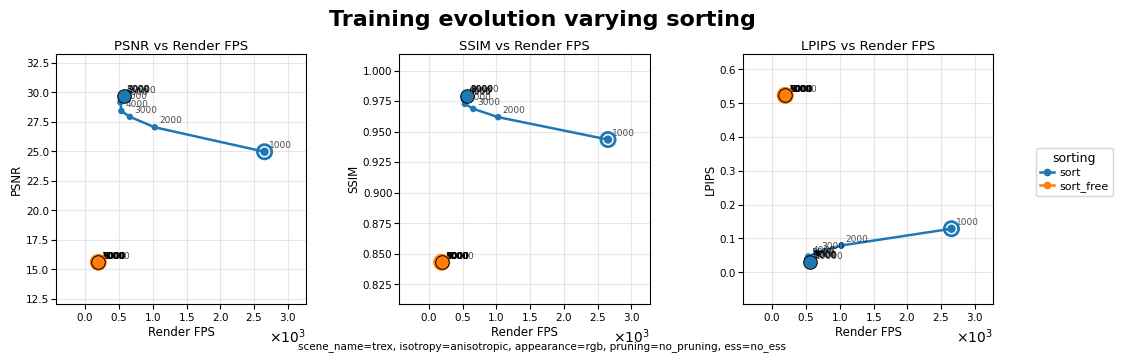

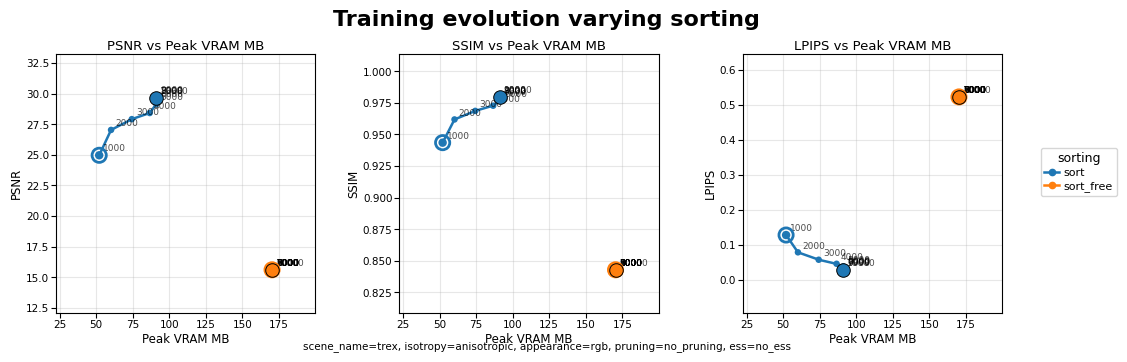

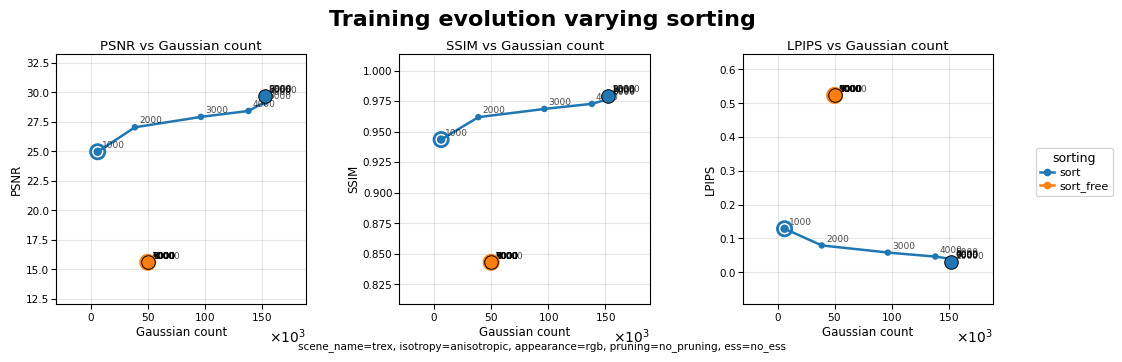

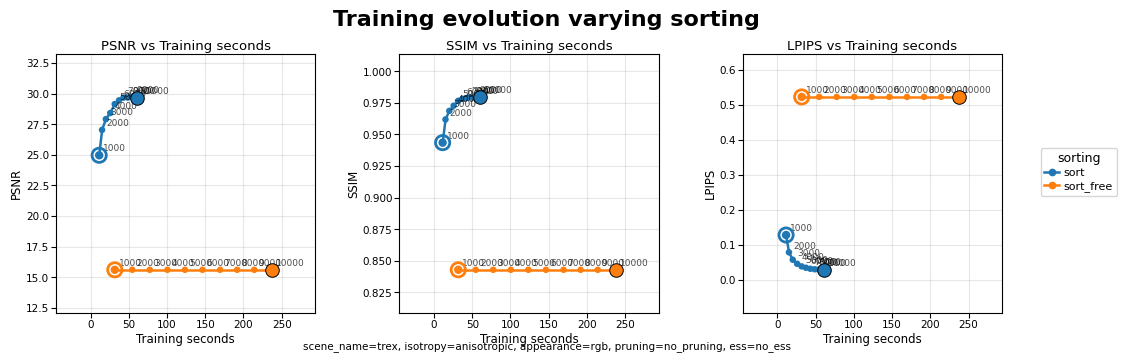

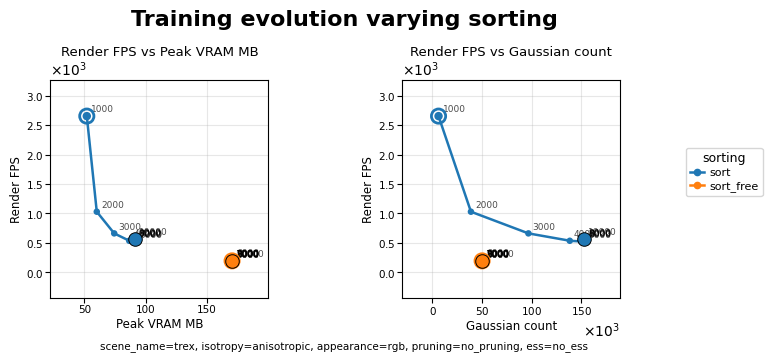

In [70]:
pareto_pairs = [
    # Quality vs rendering speed
    ("render_fps", "psnr", "Render FPS", "PSNR"),
    ("render_fps", "ssim", "Render FPS", "SSIM"),
    ("render_fps", "lpips", "Render FPS", "LPIPS"),

    # Quality vs memory
    ("peak_eval_vram_mb", "psnr", "Peak VRAM MB", "PSNR"),
    ("peak_eval_vram_mb", "ssim", "Peak VRAM MB", "SSIM"),
    ("peak_eval_vram_mb", "lpips", "Peak VRAM MB", "LPIPS"),

    # Quality vs Gaussian count / complexity
    ("final_gaussian_count", "psnr", "Gaussian count", "PSNR"),
    ("final_gaussian_count", "ssim", "Gaussian count", "SSIM"),
    ("final_gaussian_count", "lpips", "Gaussian count", "LPIPS"),

    # Quality vs training cost
    ("training_wall_clock_sec_at_checkpoint", "psnr", "Training seconds", "PSNR"),
    ("training_wall_clock_sec_at_checkpoint", "ssim", "Training seconds", "SSIM"),
    ("training_wall_clock_sec_at_checkpoint", "lpips", "Training seconds", "LPIPS"),

    # Speed vs memory / complexity
    ("peak_eval_vram_mb", "render_fps", "Peak VRAM MB", "Render FPS"),
    ("final_gaussian_count", "render_fps", "Gaussian count", "Render FPS"),

    ("checkpoint_size_mb", "psnr", "Checkpoint size MB", "PSNR"),
    ("checkpoint_size_mb", "ssim", "Checkpoint size MB", "SSIM"),
    ("checkpoint_size_mb", "lpips", "Checkpoint size MB", "LPIPS"),
    ("checkpoint_size_mb", "render_fps", "Checkpoint size MB", "Render FPS"),
]

vary_col = "sorting"

fixed_values = {
    "scene_name": "trex",
    "matrix_preset": "cartesian",
    "isotropy": "anisotropic",
    "appearance": "rgb",
    "sorting": "sort",
    "pruning": "no_pruning",
    # "dropout": "no_dropout",  # excluded because vary_col = "dropout"
    "ess": "no_ess",
}

iter_col = "eval_checkpoint_iteration"

from matplotlib.ticker import ScalarFormatter

plot_df = df_clean.copy()

for col, val in fixed_values.items():
    if col in plot_df.columns and col != vary_col:
        plot_df = plot_df[plot_df[col].astype(str) == str(val)]

if iter_col not in plot_df.columns:
    raise ValueError(f"Missing iteration column: {iter_col}")

if vary_col not in plot_df.columns:
    raise ValueError(f"Missing varying column: {vary_col}")

plot_df = plot_df.dropna(subset=[vary_col, iter_col]).copy()

available_pairs = [
    pair for pair in pareto_pairs
    if pair[0] in plot_df.columns and pair[1] in plot_df.columns
]

if not available_pairs:
    raise ValueError("No pareto pairs are available in plot_df.")

vary_values = sorted(plot_df[vary_col].astype(str).unique())

if len(vary_values) == 0:
    raise ValueError("No vary values found after filtering.")

print(
    plot_df
    .groupby(vary_col)[iter_col]
    .agg(["count", "nunique", "min", "max"])
)

cmap = plt.get_cmap("tab10")
colors = {
    value: cmap(i % cmap.N)
    for i, value in enumerate(vary_values)
}

plots_per_image = 3

fixed_text = ", ".join(
    f"{k}={v}"
    for k, v in fixed_values.items()
    if k in plot_df.columns and k != vary_col
)


class SciFormatter(ScalarFormatter):
    def __init__(self):
        super().__init__(useMathText=True)
        self.set_scientific(True)
        self.set_powerlimits((3, 3))


def use_scientific_if_large(ax):
    for axis in [ax.xaxis, ax.yaxis]:
        values = axis.get_view_interval()
        if np.nanmax(np.abs(values)) > 999:
            fmt = SciFormatter()
            axis.set_major_formatter(fmt)


def add_axis_padding(ax, x_pad_frac=0.25, y_pad_frac=0.25):
    xmin, xmax = ax.dataLim.intervalx
    ymin, ymax = ax.dataLim.intervaly

    if not np.all(np.isfinite([xmin, xmax, ymin, ymax])):
        return

    x_span = xmax - xmin
    y_span = ymax - ymin

    if x_span == 0:
        x_span = abs(xmax) if xmax != 0 else 1
    if y_span == 0:
        y_span = abs(ymax) if ymax != 0 else 1

    ax.set_xlim(xmin - x_span * x_pad_frac, xmax + x_span * x_pad_frac)
    ax.set_ylim(ymin - y_span * y_pad_frac, ymax + y_span * y_pad_frac)


def spline_xy_by_iteration(x, y, n_points=200):
    """
    Smooth a trajectory parametrically by checkpoint order.

    This works even when x is not monotonic, unlike y=f(x) splines.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return x, y

    t = np.arange(len(x), dtype=float)
    t_smooth = np.linspace(t.min(), t.max(), n_points)

    x_smooth = np.interp(t_smooth, t, x)
    y_smooth = np.interp(t_smooth, t, y)
    return x_smooth, y_smooth


for start in range(0, len(available_pairs), plots_per_image):
    pairs_chunk = available_pairs[start:start + plots_per_image]
    n_plots = len(pairs_chunk)

    fig, axes = plt.subplots(
        1,
        n_plots,
        figsize=(3.45 * n_plots + 0.75, 3.45),
        squeeze=False,
    )

    axes = axes[0]

    for ax, (x_col, y_col, x_label, y_label) in zip(axes, pairs_chunk):
        for value in vary_values:
            line_df = plot_df[plot_df[vary_col].astype(str) == value].copy()

            line_df = (
                line_df
                .groupby(iter_col, as_index=False)[[x_col, y_col]]
                .mean()
                .sort_values(iter_col)
            )

            line_df = line_df.dropna(subset=[x_col, y_col])

            if line_df.empty:
                continue

            x = line_df[x_col].to_numpy(dtype=float)
            y = line_df[y_col].to_numpy(dtype=float)
            iters = line_df[iter_col].to_numpy()

            if len(x) >= 2:
                x_smooth, y_smooth = spline_xy_by_iteration(x, y)

                ax.plot(
                    x_smooth,
                    y_smooth,
                    linewidth=1.8,
                    color=colors[value],
                    label=value,
                    zorder=2,
                )

            ax.scatter(
                x,
                y,
                s=22,
                color=colors[value],
                edgecolors="none",
                zorder=3,
            )

            # Start marker: hollow double ring
            ax.scatter(
                x[0],
                y[0],
                s=105,
                facecolors="none",
                edgecolors=[colors[value]],
                linewidths=2.0,
                zorder=4,
            )
            ax.scatter(
                x[0],
                y[0],
                s=24,
                facecolors="none",
                edgecolors=[colors[value]],
                linewidths=1.15,
                zorder=5,
            )

            # End marker: filled with black edge
            ax.scatter(
                x[-1],
                y[-1],
                s=95,
                color=colors[value],
                edgecolors="black",
                linewidths=0.7,
                zorder=6,
            )

            for xi, yi, iteration_value in zip(x, y, iters):
                ax.annotate(
                    str(int(iteration_value)),
                    (xi, yi),
                    textcoords="offset points",
                    xytext=(3, 3),
                    fontsize=6.5,
                    alpha=0.7,
                )

        add_axis_padding(ax, x_pad_frac=0.25, y_pad_frac=0.25)
        use_scientific_if_large(ax)

        ax.set_box_aspect(1)
        ax.set_title(f"{y_label} vs {x_label}", fontsize=9.5, pad=3)
        ax.set_xlabel(x_label, fontsize=8.5, labelpad=2)
        ax.set_ylabel(y_label, fontsize=8.5, labelpad=2)
        ax.tick_params(axis="both", labelsize=7.5, pad=1.5)
        ax.grid(alpha=0.3)

    handles = [
        plt.Line2D(
            [0],
            [0],
            color=colors[value],
            marker="o",
            linewidth=1.8,
            markersize=4.5,
            label=value,
        )
        for value in vary_values
    ]

    fig.legend(
        handles=handles,
        labels=vary_values,
        title=vary_col,
        loc="center left",
        bbox_to_anchor=(0.94, 0.52),
        ncol=1,
        frameon=True,
        fontsize=8,
        title_fontsize=9,
        borderpad=0.35,
        labelspacing=0.3,
        handlelength=1.3,
        handletextpad=0.45,
    )

    fig.suptitle(
        f"Training evolution varying {vary_col}",
        y=0.99,
        fontsize=16,
        fontweight="bold",
    )

    fig.text(
        0.5,
        0.006,
        fixed_text,
        ha="center",
        fontsize=7.5,
    )

    plt.tight_layout(
        rect=[0.002, 0.028, 0.925, 0.955],
        pad=0.15,
        w_pad=0.25,
        h_pad=0.0,
    )

    plt.show()

,sorting,psnr,ssim,lpips,render_fps,peak_eval_vram_mb,training_wall_clock_sec_at_checkpoint,final_gaussian_count
0,sort,28.660116,0.972488,0.048911,791.447132,82.726873,37.015858,122482.636364
1,sort_free,15.600850,0.842924,0.522818,191.891635,170.357422,143.978152,50000.000000


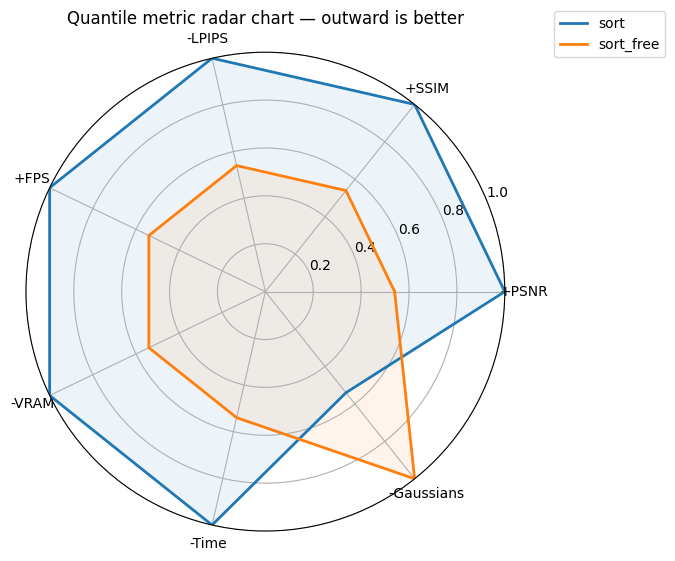

In [58]:
# %%
vary_col = "sorting"

fixed_values = {
    "scene_name": "trex",
    "matrix_preset": "cartesian",
    "isotropy": "anisotropic",
    "appearance": "rgb",
    "sorting": "sort",
    "pruning": "no_pruning",
    # "dropout": "no_dropout",  # excluded because vary_col = "dropout"
    "ess": "no_ess",
}

display_cols = [
    "psnr",
    "ssim",
    "lpips",
    "render_fps",
    "peak_eval_vram_mb",
    "checkpoint_size_mb",
    "training_wall_clock_sec_at_checkpoint",
    "final_gaussian_count",
]

radar_specs = {
    "+PSNR": {
        "col": "psnr",
        "higher_is_better": True,
    },
    "+SSIM": {
        "col": "ssim",
        "higher_is_better": True,
    },
    "-LPIPS": {
        "col": "lpips",
        "higher_is_better": False,
    },
    "+FPS": {
        "col": "render_fps",
        "higher_is_better": True,
    },
    "-VRAM": {
        "col": "peak_eval_vram_mb",
        "higher_is_better": False,
    },
    "-Size": {
        "col": "checkpoint_size_mb",
        "higher_is_better": False,
    },
    "-Time": {
        "col": "training_wall_clock_sec_at_checkpoint",
        "higher_is_better": False,
    },
    "-Gaussians": {
        "col": "final_gaussian_count",
        "higher_is_better": False,
    },
}

quantile_floor = 0.08

plot_df = df_clean.copy()

for col, val in fixed_values.items():
    if col in plot_df.columns and col != vary_col:
        plot_df = plot_df[plot_df[col].astype(str) == str(val)]

if vary_col not in plot_df.columns:
    raise ValueError(f"Missing varying column: {vary_col}")

available_display_cols = [
    col for col in display_cols
    if col in plot_df.columns
]

if not available_display_cols:
    raise ValueError("No display columns are available in plot_df.")

available_radar_specs = {
    label: spec
    for label, spec in radar_specs.items()
    if spec["col"] in plot_df.columns
}

if not available_radar_specs:
    raise ValueError("No radar columns are available in plot_df.")

plot_df = plot_df.dropna(subset=[vary_col]).copy()

summary_df = (
    plot_df
    .groupby(vary_col, as_index=False)[available_display_cols]
    .mean()
)

display(summary_df[[vary_col] + available_display_cols])

def quantile_score(x, higher_is_better=True, floor=0.08):
    x = pd.to_numeric(x, errors="coerce")

    ranks = x.rank(
        method="average",
        pct=True,
        ascending=higher_is_better,
    )

    return floor + (1.0 - floor) * ranks

radar_cols = {}

for label, spec in available_radar_specs.items():
    radar_cols[label] = quantile_score(
        summary_df[spec["col"]],
        higher_is_better=spec["higher_is_better"],
        floor=quantile_floor,
    )

radar = pd.DataFrame(radar_cols)
radar["label"] = summary_df[vary_col].astype(str)

categories = list(radar_cols.keys())
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

for _, row in radar.iterrows():
    values = row[categories].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=row["label"])
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title("Quantile metric radar chart — outward is better")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.show()

In [96]:
import matplotlib.colors as mcolors

def plot_grouped_quantile_heatmap(
    df,
    filter_values,
    model_spec_cols,
    metric_cols,
    high_better_cols=None,
    low_better_cols=None,
    group_cols=None,
    heatmap_cols=None,
    sort_by="mean_quantile_score",
    sort_ascending=None,
    dedupe=True,
    cell_fontsize=6,
    xtick_fontsize=8,
    ytick_fontsize=7.5,
    cell_sigfigs=2,
    cmap_name="RdYlGn",
    title_prefix="Grouped heatmap",
):
    high_better_cols = set(high_better_cols or {
        "psnr",
        "ssim",
        "render_fps",
        "fps",
    })

    low_better_cols = set(low_better_cols or {
        "lpips",
        "peak_eval_vram_mb",
        "checkpoint_size_mb",
        "training_wall_clock_sec_at_checkpoint",
        "final_gaussian_count",
        "vram",
        "size",
        "time",
        "gaussians",
    })

    df_heat = df.copy()

    for col, value in filter_values:
        if col not in df_heat.columns:
            raise ValueError(f"Missing filter column: {col}")

        if isinstance(value, (list, tuple, set)):
            df_heat = df_heat[df_heat[col].isin(value)]
        else:
            df_heat = df_heat[df_heat[col] == value]

    if df_heat.empty:
        raise ValueError("No rows left after filtering.")

    iter_col = (
        "eval_checkpoint_iteration"
        if "eval_checkpoint_iteration" in df_heat.columns
        else "checkpoint_name_iteration"
    )

    if dedupe:
        dedupe_cols = [c for c in ["run_hash", iter_col] if c in df_heat.columns]

        if dedupe_cols:
            if "created_at" in df_heat.columns:
                df_heat = df_heat.sort_values("created_at")

            df_heat = df_heat.drop_duplicates(subset=dedupe_cols, keep="last")

    fixed_cols = {col for col, _ in filter_values}

    if group_cols is None:
        group_cols = [
            c for c in model_spec_cols
            if c in df_heat.columns
            and c not in fixed_cols
            and c not in {"run_hash", "created_at"}
            and df_heat[c].nunique(dropna=False) > 1
        ]
    else:
        group_cols = [c for c in group_cols if c in df_heat.columns]

    if not group_cols:
        raise ValueError("No grouping columns found. Pass group_cols manually.")

    if heatmap_cols is None:
        heatmap_cols = [
            c for c in metric_cols
            if c in df_heat.columns
            and pd.api.types.is_numeric_dtype(df_heat[c])
        ]
    else:
        heatmap_cols = [
            c for c in heatmap_cols
            if c in df_heat.columns
            and pd.api.types.is_numeric_dtype(df_heat[c])
        ]

    if not heatmap_cols:
        raise ValueError("No numeric heatmap columns available.")

    df_grouped = (
        df_heat
        .groupby(group_cols, dropna=False, as_index=False)[heatmap_cols]
        .mean()
        .sort_values(group_cols)
        .reset_index(drop=True)
    )

    def quantile_best_score(s, col):
        s = pd.to_numeric(s, errors="coerce")

        if col in low_better_cols:
            return s.rank(method="average", pct=True, ascending=False)

        return s.rank(method="average", pct=True, ascending=True)

    heatmap_scores = pd.DataFrame(
        {
            col: quantile_best_score(df_grouped[col], col)
            for col in heatmap_cols
        },
        index=df_grouped.index,
    )

    mean_quantile_score = heatmap_scores.mean(axis=1, skipna=True)

    sortable = df_grouped.copy()
    sortable["mean_quantile_score"] = mean_quantile_score

    if isinstance(sort_by, str):
        sort_by = [sort_by]
    else:
        sort_by = list(sort_by)

    missing_sort_cols = [c for c in sort_by if c not in sortable.columns]
    if missing_sort_cols:
        raise ValueError(f"Missing sort column(s): {missing_sort_cols}")

    if sort_ascending is None:
        sort_ascending = []
        for col in sort_by:
            if col == "mean_quantile_score":
                sort_ascending.append(False)
            elif col in heatmap_cols:
                sort_ascending.append(col in low_better_cols)
            else:
                sort_ascending.append(True)
    elif isinstance(sort_ascending, bool):
        sort_ascending = [sort_ascending] * len(sort_by)
    else:
        sort_ascending = list(sort_ascending)

    if len(sort_ascending) != len(sort_by):
        raise ValueError("sort_ascending must be a bool or match len(sort_by).")

    sort_order = (
        sortable
        .sort_values(sort_by, ascending=sort_ascending, kind="mergesort")
        .index
    )

    df_grouped = df_grouped.loc[sort_order].reset_index(drop=True)
    heatmap_scores = heatmap_scores.loc[sort_order].reset_index(drop=True)
    mean_quantile_score = mean_quantile_score.loc[sort_order].reset_index(drop=True)

    row_labels = (
        df_grouped[group_cols]
        .astype(str)
        .agg(" | ".join, axis=1)
    )

    filter_text = ", ".join(
        f"{col}={value}"
        for col, value in filter_values
    )

    sort_text = ", ".join(
        f"{col} {'ascending' if asc else 'descending'}"
        for col, asc in zip(sort_by, sort_ascending)
    )

    fig_width = max(8, 0.7 * len(heatmap_cols))
    fig_height = max(4.5, 0.34 * len(df_grouped))

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=0, vmax=1)

    im = ax.imshow(
        heatmap_scores.to_numpy(dtype=float),
        aspect="auto",
        cmap=cmap,
        norm=norm,
    )

    ax.set_xticks(np.arange(len(heatmap_cols)))
    ax.set_xticklabels(
        heatmap_cols,
        rotation=45,
        ha="right",
        fontsize=xtick_fontsize,
    )

    ax.set_yticks(np.arange(len(df_grouped)))
    ax.set_yticklabels(row_labels, fontsize=ytick_fontsize)

    for i in range(len(df_grouped)):
        for j, col in enumerate(heatmap_cols):
            value = df_grouped.iloc[i][col]

            if pd.isna(value):
                text = ""
            else:
                text = f"{value:.{cell_sigfigs}g}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=cell_fontsize,
                color="black",
            )

    ax.set_title(
        f"{title_prefix}\n"
        f"Filtered to: {filter_text}\n"
        f"Rows sorted by: {sort_text}",
        fontsize=12,
        pad=12,
    )

    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.032,
        pad=0.015,
        shrink=1.0,
        aspect=22,
    )
    cbar.set_label("Column-wise quantile score", rotation=270, labelpad=16)

    plt.tight_layout()
    plt.show()

    df_grouped = df_grouped.copy()
    df_grouped.insert(0, "mean_quantile_score", mean_quantile_score)

    return df_grouped, heatmap_scores

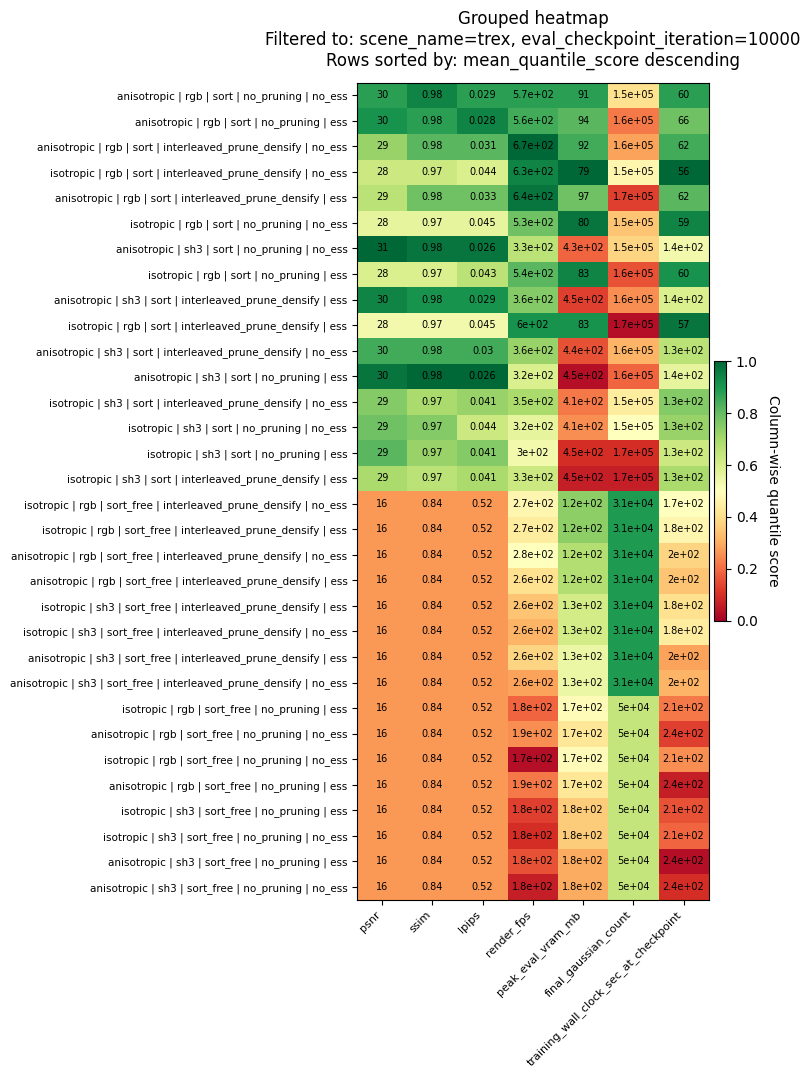

In [100]:
df_grouped, heatmap_scores = plot_grouped_quantile_heatmap(
    df=df_summary,
    filter_values=[
        ("scene_name", "trex"),
        (iter_col, 10000),
    ],
    model_spec_cols=model_spec_cols,
    metric_cols=metric_cols,
    group_cols=[
        "matrix_preset",
        "isotropy",
        "appearance",
        "sorting",
        "pruning",
        "dropout",
        "ess",
    ],
    cell_fontsize=7,
)

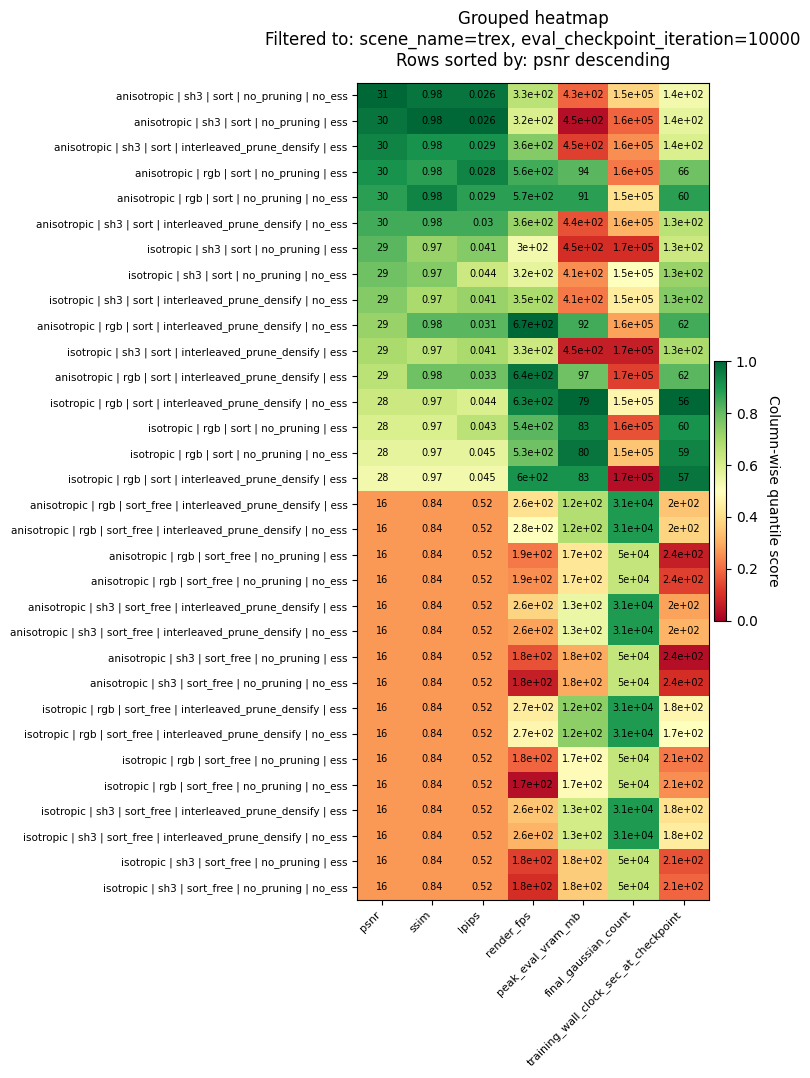

In [101]:
df_grouped, heatmap_scores = plot_grouped_quantile_heatmap(
    df=df_summary,
    filter_values=[
        ("scene_name", "trex"),
        (iter_col, 10000),
    ],
    model_spec_cols=model_spec_cols,
    metric_cols=metric_cols,
    group_cols=[
        "matrix_preset",
        "isotropy",
        "appearance",
        "sorting",
        "pruning",
        "dropout",
        "ess",
    ],
    sort_by="psnr",
    cell_fontsize=7,
)